Epoch 1/50
4/4 [==============================] - 2s 165ms/step - loss: 0.6453 - accuracy: 0.7048 - val_loss: 0.5778 - val_accuracy: 0.9333
Epoch 2/50
4/4 [==============================] - 0s 28ms/step - loss: 0.5943 - accuracy: 0.9714 - val_loss: 0.5218 - val_accuracy: 0.9778
Epoch 3/50
4/4 [==============================] - 0s 37ms/step - loss: 0.5475 - accuracy: 0.9905 - val_loss: 0.4734 - val_accuracy: 0.9778
Epoch 4/50
4/4 [==============================] - 0s 36ms/step - loss: 0.5067 - accuracy: 0.9905 - val_loss: 0.4312 - val_accuracy: 1.0000
Epoch 5/50
4/4 [==============================] - 0s 44ms/step - loss: 0.4692 - accuracy: 0.9905 - val_loss: 0.3942 - val_accuracy: 1.0000
Epoch 6/50
4/4 [==============================] - 0s 34ms/step - loss: 0.4346 - accuracy: 1.0000 - val_loss: 0.3620 - val_accuracy: 1.0000
Epoch 7/50
4/4 [==============================] - 0s 39ms/step - loss: 0.4034 - accuracy: 1.0000 - val_loss: 0.3323 - val_accuracy: 1.0000
Epoch 8/50
4/4 [==========

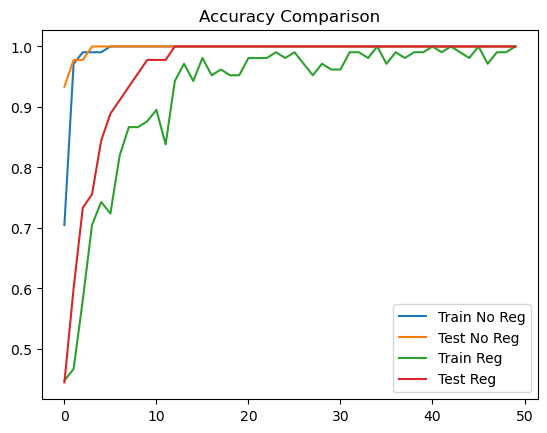

2/2 [==============================] - 0s 6ms/step

--- Without Regularization ---
Confusion Matrix:
 [[26  0]
 [ 0 19]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        26
           1       1.00      1.00      1.00        19

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45


--- With Regularization ---
Confusion Matrix:
 [[26  0]
 [ 0 19]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        26
           1       1.00      1.00      1.00        19

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2

# Load dataset
data = load_iris()
X = data.data
y = data.target

# Convert to binary classification (class 0 vs others)
y = (y == 0).astype(int)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -----------------------------
# Model 1: Without Regularization
# -----------------------------
model_no_reg = Sequential([
    Dense(32, activation='relu', input_shape=(X.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_no_reg.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_no_reg = model_no_reg.fit(X_train, y_train,
                                 validation_data=(X_test, y_test),
                                 epochs=50, verbose=1)

# -----------------------------
# Model 2: With Regularization
# -----------------------------
model_reg = Sequential([
    Dense(32, activation='relu', kernel_regularizer=l2(0.01), input_shape=(X.shape[1],)),
    Dropout(0.4),
    Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

model_reg.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_reg = model_reg.fit(X_train, y_train,
                           validation_data=(X_test, y_test),
                           epochs=50, verbose=1)

# -----------------------------
# Plot Accuracy
# -----------------------------
plt.plot(history_no_reg.history['accuracy'], label='Train No Reg')
plt.plot(history_no_reg.history['val_accuracy'], label='Test No Reg')

plt.plot(history_reg.history['accuracy'], label='Train Reg')
plt.plot(history_reg.history['val_accuracy'], label='Test Reg')

plt.title("Accuracy Comparison")
plt.legend()
plt.show()

# -----------------------------
# Predictions
# -----------------------------
y_pred_no_reg = (model_no_reg.predict(X_test) > 0.5).astype(int)
y_pred_reg = (model_reg.predict(X_test) > 0.5).astype(int)

# -----------------------------
# Evaluation Metrics
# -----------------------------
print("\n--- Without Regularization ---")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_no_reg))
print("Classification Report:\n", classification_report(y_test, y_pred_no_reg))

print("\n--- With Regularization ---")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_reg))
print("Classification Report:\n", classification_report(y_test, y_pred_reg))